# CART & PRIM Analysis: Scenario Discovery for Net-Zero Pathways

This notebook performs scenario discovery to identify which factors distinguish pathways that achieve net-zero CO2 emissions by 2070 with low reliance on carbon capture and storage (CCS).

**Analysis Steps:**
1. Load and prepare pathway data
2. Define desired outcome space (net zero by 2070 + low CCS)
3. CART analysis to identify key splitting variables
4. PRIM analysis to find high-density regions of successful pathways

**Data Source:** Scenario Compass Initiative (SCI) 2025 pathways ensemble

In [15]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ema_workbench.analysis import cart, prim

pd.set_option("display.max_columns", 60)
print("Libraries loaded successfully")
print("\nNote: If Excel file loading fails, install python-calamine:")
print("  pip install python-calamine")

Libraries loaded successfully

Note: If Excel file loading fails, install python-calamine:
  pip install python-calamine


## 1. Load Data

Loading the SCI 2025 pathways ensemble. We need both:
- **meta sheet**: Contains pre-calculated diagnostics (net-zero year, cumulative CCS)
- **data sheet**: Contains time series for pathway variables

Note: Using Excel file to access both sheets. CSV only contains the data sheet.

In [16]:
# Data paths
XLSX_PATH = r"C:\Users\5982758\OneDrive - Universiteit Utrecht\Documents\Courses\2026_PRISMA\robust decision making\raw\SCI-2025_v1.0_pathways_ensemble_global.xlsx"
ENGINE = "calamine"  # Fast Excel reader

# Load meta sheet (one row per Model-Scenario with diagnostics)
meta = pd.read_excel(XLSX_PATH, sheet_name="meta", engine=ENGINE)
print(f"Meta sheet: {meta.shape[0]} scenarios × {meta.shape[1]} columns")
print(f"Unique models: {meta['Model'].nunique()}")

# Load data sheet (long IAMC format with time series)
df = pd.read_excel(XLSX_PATH, sheet_name="data", engine=ENGINE)
print(f"\nData sheet: {df.shape[0]:,} rows")
print(f"Unique Model-Scenario combinations: {df.groupby(['Model', 'Scenario']).ngroups}")

Meta sheet: 1599 scenarios × 71 columns
Unique models: 65

Data sheet: 548,541 rows
Unique Model-Scenario combinations: 1599


In [17]:
# Convert data sheet to long format
time_cols = [col for col in df.columns if col.isdigit()]
df_long = df.melt(
    id_vars=['Model', 'Scenario', 'Region', 'Variable', 'Unit'],
    value_vars=time_cols,
    var_name='Year',
    value_name='Value'
)
df_long['Year'] = df_long['Year'].astype(int)
df_long['scenario_id'] = df_long['Model'] + ' | ' + df_long['Scenario']

# Add scenario_id to meta for joining
meta['scenario_id'] = meta['Model'] + ' | ' + meta['Scenario']

print(f"Long format: {df_long.shape[0]:,} rows")
print(f"Unique Model-Scenario combinations: {df_long['scenario_id'].nunique()}")
df_long.head()

Long format: 10,422,279 rows
Unique Model-Scenario combinations: 1599


,Model,Scenario,Region,Variable,Unit,Year,Value,scenario_id
0,AIM/CGE 2.0,SSP1-19,World,Agricultural Demand|Crops,million t DM/yr,2010,3489.8126,AIM/CGE 2.0 | SSP1-19
1,AIM/CGE 2.0,SSP1-19,World,Agricultural Demand|Livestock,million t DM/yr,2010,195.2943,AIM/CGE 2.0 | SSP1-19
2,AIM/CGE 2.0,SSP1-19,World,Agricultural Production|Crops|Energy Crops,million t DM/yr,2010,0.0000,AIM/CGE 2.0 | SSP1-19
3,AIM/CGE 2.0,SSP1-19,World,Capacity|Electricity,GW,2010,4164.7229,AIM/CGE 2.0 | SSP1-19
4,AIM/CGE 2.0,SSP1-19,World,Capacity|Electricity|Biomass,GW,2010,61.5660,AIM/CGE 2.0 | SSP1-19


## 2. Define Desired Outcome Space

We define the "desired" pathway space as scenarios that meet **both** criteria:
1. **Net zero by 2070**: Reaches net-zero CO2 at or before 2070 (from meta diagnostics)
2. **Low CCS reliance**: Cumulative CCS over 2020-2100 ≤ ensemble median (from meta diagnostics)

This refinement distinguishes pathways achieving net zero through early mitigation from those relying heavily on carbon capture.

**Using pre-calculated diagnostics from meta sheet** (not computing from time series).

In [18]:
# Extract net-zero year diagnostic from meta sheet
NZ_COL = "Emissions Diagnostics|Year of Net Zero|CO2"

if NZ_COL not in meta.columns:
    raise ValueError(f"Column '{NZ_COL}' not found in meta sheet. Available columns: {meta.columns.tolist()}")

# Define net-zero success: reaches net zero at or before 2070
# NaN means never reaches net zero within model horizon -> treated as failure
meta['net_zero_by_2070'] = meta[NZ_COL].le(2070)

print(f"Total scenarios in meta: {len(meta)}")
print(f"Net zero by 2070: {meta['net_zero_by_2070'].sum()} scenarios")
print(f"Not net zero by 2070: {(~meta['net_zero_by_2070']).sum()} scenarios")
print(f"\nNet zero year statistics:")
print(meta[NZ_COL].describe())

Total scenarios in meta: 1599
Net zero by 2070: 497 scenarios
Not net zero by 2070: 1102 scenarios

Net zero year statistics:
count     909.000000
mean     2070.380638
std        14.398448
min      2030.000000
25%      2060.000000
50%      2070.000000
75%      2080.000000
max      2100.000000
Name: Emissions Diagnostics|Year of Net Zero|CO2, dtype: float64


In [19]:
# Extract cumulative CCS diagnostic from meta sheet
CCS_COL = "Emissions Diagnostics|Cumulative CCS [2020-2100, Gt CO2]"

if CCS_COL not in meta.columns:
    # Try alternative column names
    ccs_candidates = [col for col in meta.columns if 'Cumulative CCS' in col or ('CCS' in col and 'Cumulative' in col)]
    if ccs_candidates:
        CCS_COL = ccs_candidates[0]
        print(f"Using alternative CCS column: {CCS_COL}")
    else:
        raise ValueError(f"No cumulative CCS column found. Available columns: {[c for c in meta.columns if 'CCS' in c or 'Carbon' in c]}")

print(f"Using cumulative CCS from: {CCS_COL}")
print(f"Scenarios with CCS data: {meta[CCS_COL].notna().sum()}")
print(f"Missing CCS data: {meta[CCS_COL].isna().sum()}")

Using cumulative CCS from: Emissions Diagnostics|Cumulative CCS [2020-2100, Gt CO2]
Scenarios with CCS data: 1509
Missing CCS data: 90


In [20]:
# Define low CCS reliance: cumulative CCS ≤ ensemble median
ccs_median = meta[CCS_COL].median()
meta['low_ccs_reliance'] = meta[CCS_COL] <= ccs_median

print(f"Cumulative CCS median (2020-2100): {ccs_median:.1f} Gt CO2")
print(f"Low CCS reliance (≤ median): {meta['low_ccs_reliance'].sum()} scenarios")
print(f"High CCS reliance (> median): {(~meta['low_ccs_reliance'] & meta[CCS_COL].notna()).sum()} scenarios")
print(f"Missing CCS data: {meta[CCS_COL].isna().sum()} scenarios")

Cumulative CCS median (2020-2100): 493.2 Gt CO2
Low CCS reliance (≤ median): 755 scenarios
High CCS reliance (> median): 754 scenarios
Missing CCS data: 90 scenarios


In [21]:
# Combine criteria: desired outcome = net zero by 2070 AND low CCS reliance
meta['desired_outcome'] = meta['net_zero_by_2070'] & meta['low_ccs_reliance']

# Create indexed version for later joining
desired_outcome = meta.set_index('scenario_id')['desired_outcome']

print(f"\nScenarios with both indicators available: {(meta['net_zero_by_2070'].notna() & meta['low_ccs_reliance'].notna()).sum()}")
print(f"Desired outcome (Net Zero + Low CCS): {meta['desired_outcome'].sum()} scenarios")
print(f"Net Zero only (high CCS): {(meta['net_zero_by_2070'] & ~meta['low_ccs_reliance'] & meta[CCS_COL].notna()).sum()} scenarios")
print(f"High CCS only (not net zero): {(~meta['net_zero_by_2070'] & meta['low_ccs_reliance']).sum()} scenarios")
print(f"Neither: {(~meta['net_zero_by_2070'] & ~meta['low_ccs_reliance'] & meta[CCS_COL].notna()).sum()} scenarios")

# Create cross-tab
crosstab = pd.crosstab(
    meta['net_zero_by_2070'], 
    meta['low_ccs_reliance'], 
    rownames=['Net Zero by 2070'], 
    colnames=['Low CCS Reliance'],
    margins=True,
    dropna=False
)
print("\nCross-tabulation:")
print(crosstab)


Scenarios with both indicators available: 1599
Desired outcome (Net Zero + Low CCS): 108 scenarios
Net Zero only (high CCS): 372 scenarios
High CCS only (not net zero): 647 scenarios
Neither: 382 scenarios

Cross-tabulation:
Low CCS Reliance  False  True   All
Net Zero by 2070                   
False               455   647  1102
True                389   108   497
All                 844   755  1599


In [22]:
# Verify total scenarios meeting both criteria
total_desired = meta['desired_outcome'].sum()
print(f"\n{'='*60}")
print(f"TOTAL SCENARIOS MEETING BOTH CRITERIA: {total_desired}")
print(f"{'='*60}")
print(f"These {total_desired} scenarios are the 'cases of interest' for PRIM.")
print(f"PRIM will identify regions with HIGH concentration of these scenarios.")
print(f"\nExpected: ~372 scenarios based on SCI 2025 ensemble characteristics")


TOTAL SCENARIOS MEETING BOTH CRITERIA: 108
These 108 scenarios are the 'cases of interest' for PRIM.
PRIM will identify regions with HIGH concentration of these scenarios.

Expected: ~372 scenarios based on SCI 2025 ensemble characteristics


## 3. Prepare Feature Matrix for CART/PRIM

Extract key pathway descriptor variables at a specific year (2030) to use as features for scenario discovery.

In [23]:
# Variables of interest for analysis
ANALYSIS_YEAR = 2030
VARIABLES_OF_INTEREST = [
    'Emissions|CO2',
    'Primary Energy|Fossil',
    'Primary Energy|Biomass',
    'Primary Energy|Non-Biomass Renewables',
    'Primary Energy|Nuclear',
    'Carbon Capture|Geological Storage',
    'Final Energy|Electricity',
    'Climate Assessment|Surface Temperature (GSAT)|Median [MAGICCv7.5.3]'
]

print(f"Extracting {len(VARIABLES_OF_INTEREST)} variables at year {ANALYSIS_YEAR}:")
for var in VARIABLES_OF_INTEREST:
    print(f"  • {var}")

Extracting 8 variables at year 2030:
  • Emissions|CO2
  • Primary Energy|Fossil
  • Primary Energy|Biomass
  • Primary Energy|Non-Biomass Renewables
  • Primary Energy|Nuclear
  • Carbon Capture|Geological Storage
  • Final Energy|Electricity
  • Climate Assessment|Surface Temperature (GSAT)|Median [MAGICCv7.5.3]


In [24]:
# Extract data for each variable at the analysis year
data_for_analysis = []
variables_extracted = []

for var in VARIABLES_OF_INTEREST:
    var_data = df_long[(df_long['Variable'] == var) & (df_long['Year'] == ANALYSIS_YEAR)]
    
    if len(var_data) > 0:
        var_pivot = var_data.set_index('scenario_id')['Value']
        data_for_analysis.append(var_pivot)
        variables_extracted.append(var)
        coverage = var_pivot.notna().sum() / len(var_pivot) if len(var_pivot) > 0 else 0
        print(f"  ✓ {var}: {coverage:.1%} coverage")
    else:
        print(f"  ✗ {var}: Not available")

print(f"\nSuccessfully extracted {len(variables_extracted)} variables")

  ✓ Emissions|CO2: 99.7% coverage
  ✓ Primary Energy|Fossil: 100.0% coverage
  ✓ Primary Energy|Biomass: 100.0% coverage
  ✓ Primary Energy|Non-Biomass Renewables: 100.0% coverage
  ✓ Primary Energy|Nuclear: 100.0% coverage
  ✓ Carbon Capture|Geological Storage: 100.0% coverage
  ✓ Final Energy|Electricity: 100.0% coverage
  ✓ Climate Assessment|Surface Temperature (GSAT)|Median [MAGICCv7.5.3]: 100.0% coverage

Successfully extracted 8 variables


In [25]:
# Create feature matrix (X) and outcome vector (y)
# Align all data to common scenarios
if len(variables_extracted) > 0:
    X_raw = pd.DataFrame({var: data_for_analysis[i] for i, var in enumerate(variables_extracted)})
    
    # Add Model Family for context
    scenario_to_model = df_long[['scenario_id', 'Model']].drop_duplicates().set_index('scenario_id')['Model']
    
    def get_model_family(model_name):
        """Aggregate models into families"""
        if pd.isna(model_name):
            return 'Unknown'
        for family in ['REMIND', 'MESSAGE', 'IMAGE', 'WITCH', 'GCAM', 'AIM', 'POLES', 'IMACLIM']:
            if family in model_name:
                return family
        return model_name.split()[0]
    
    X_raw['Model_Family'] = X_raw.index.map(lambda sid: get_model_family(scenario_to_model.get(sid, 'Unknown')))
    
    # Align with outcome
    common_scenarios = X_raw.index.intersection(desired_outcome.index)
    X = X_raw.loc[common_scenarios].copy()
    y = desired_outcome.loc[common_scenarios].values
    
    print(f"Feature matrix: {X.shape[0]} scenarios × {X.shape[1]} features")
    print(f"Desired outcome: {y.sum()} successes, {(~y).sum()} failures")
else:
    raise ValueError("No variables were successfully extracted")

Feature matrix: 1591 scenarios × 9 features
Desired outcome: 108 successes, 1483 failures


In [26]:
# Handle missing values
# Keep only rows with at least 50% of variables populated
min_variables = 0.5 * len(variables_extracted)
valid_rows = X[variables_extracted].notna().sum(axis=1) >= min_variables
X = X[valid_rows]
y = y[valid_rows]

# Fill remaining NaNs with median values
for col in variables_extracted:
    if X[col].isna().any():
        median_val = X[col].median()
        if np.isnan(median_val):
            median_val = 0
        X[col].fillna(median_val, inplace=True)
        
print(f"After filtering and imputation: {X.shape[0]} scenarios")
print(f"Desired outcome distribution: {y.sum()} successes ({y.sum()/len(y):.1%}), {(~y).sum()} failures ({(~y).sum()/len(y):.1%})")

After filtering and imputation: 1584 scenarios
Desired outcome distribution: 108 successes (6.8%), 1476 failures (93.2%)


C:\Users\5982758\AppData\Local\Temp\ipykernel_26300\2691914281.py:14: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  X[col].fillna(median_val, inplace=True)
C:\Users\5982758\AppData\Local\Temp\ipykernel_26300\2691914281.py:14: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment us

## 4. CART Analysis

Classification and Regression Tree (CART) identifies which variables and thresholds best distinguish scenarios in the desired space from those outside it.

In [27]:
# Build CART tree
cart_alg = cart.CART(X[variables_extracted], y)
cart_alg.build_tree()

print(f"CART tree built successfully")
print(f"Tree depth: {cart_alg.clf.get_depth()}")
print(f"Number of leaves: {cart_alg.clf.get_n_leaves()}")

CART tree built successfully
Tree depth: 6
Number of leaves: 11


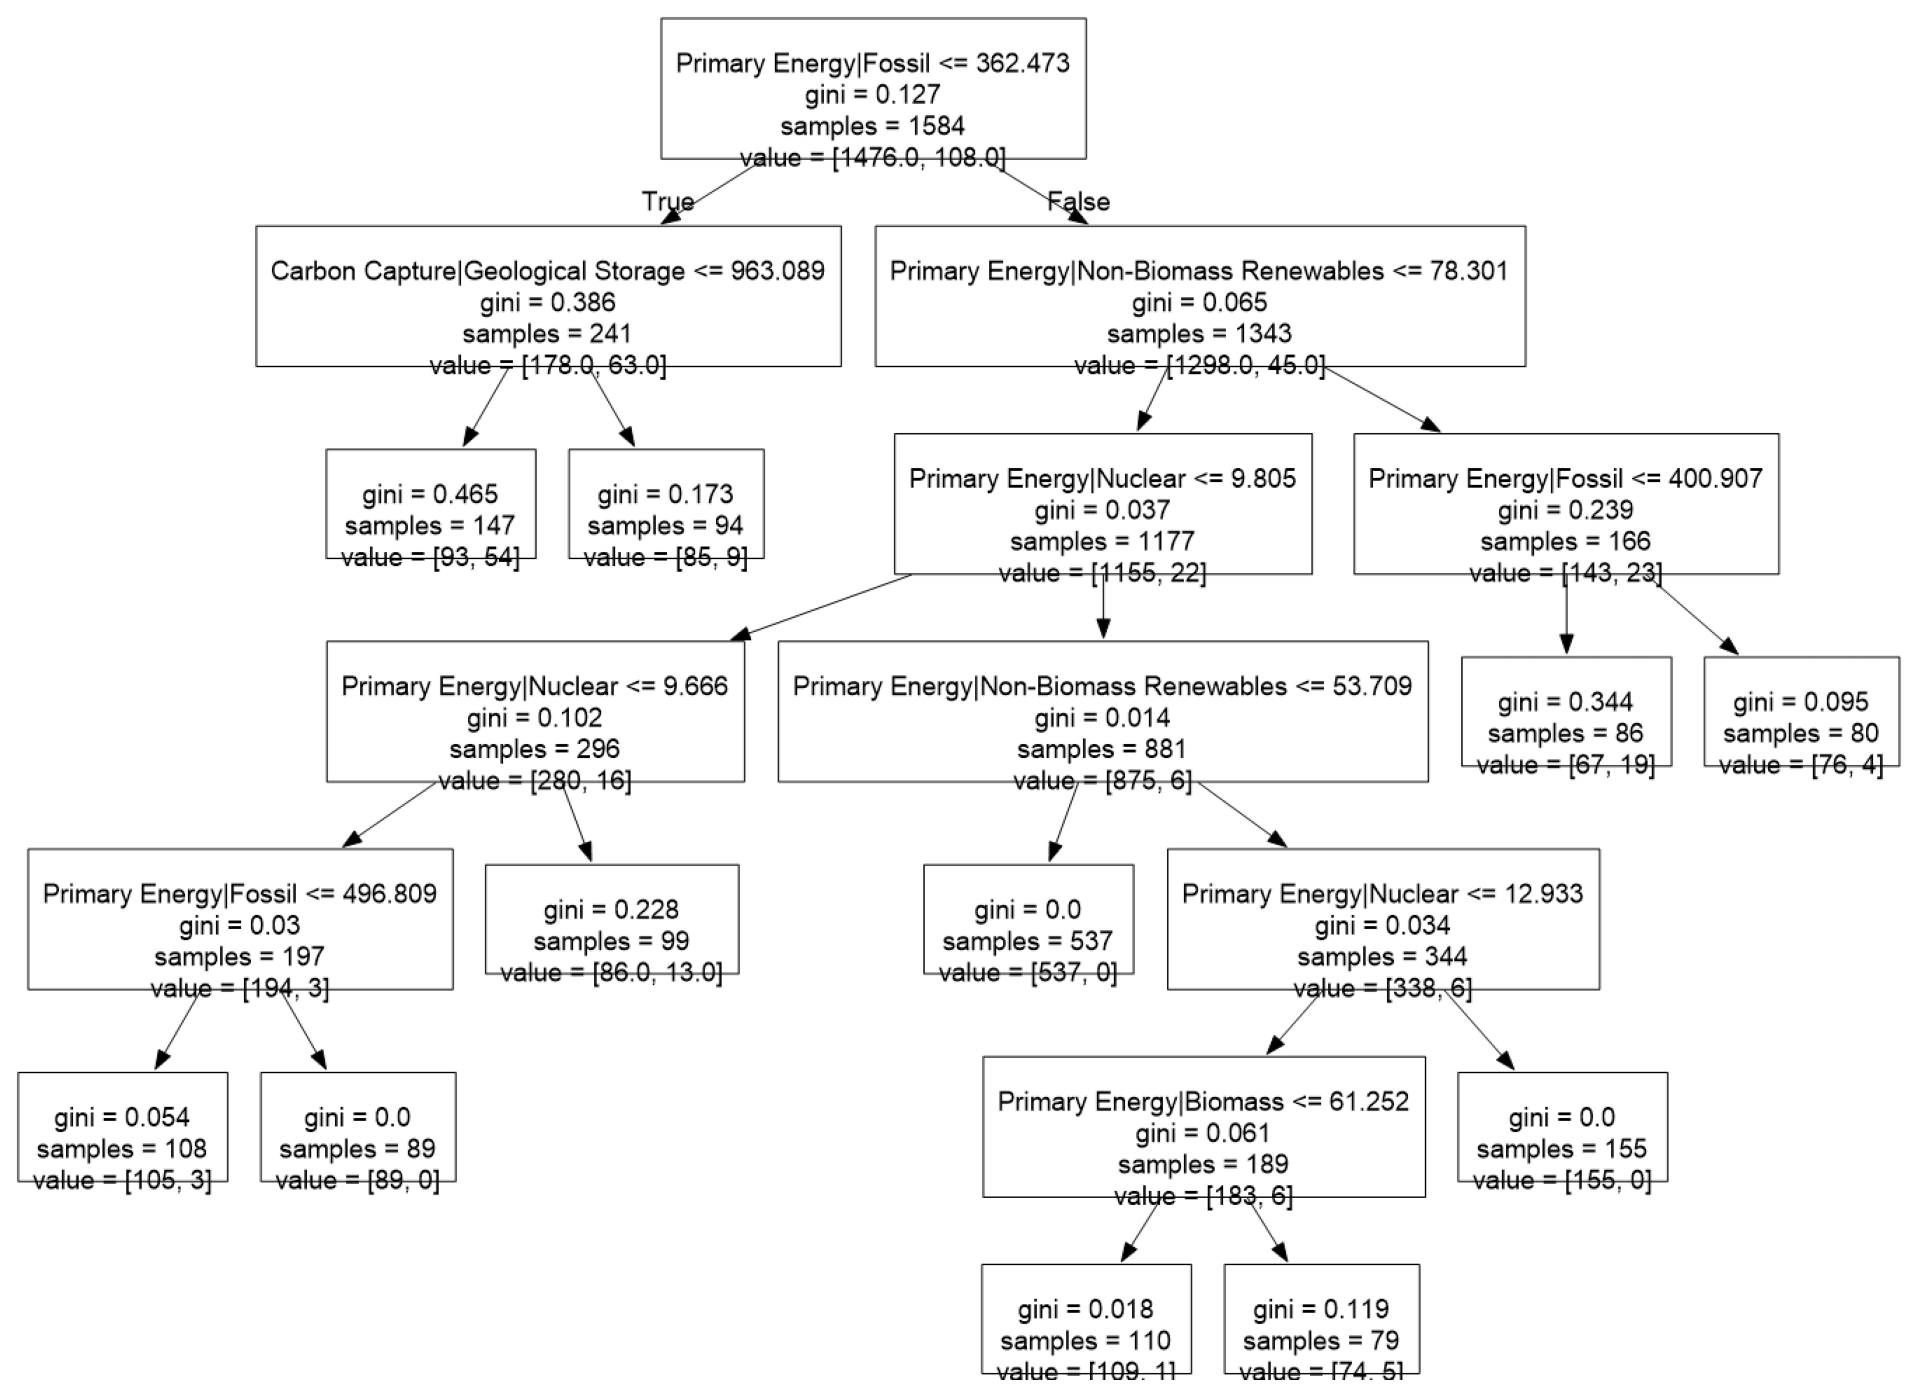


CART tree shows the decision rules that best separate desired pathways from others.


In [28]:
# Visualize CART tree
fig = cart_alg.show_tree()
fig.set_size_inches((20, 14))
plt.tight_layout()
plt.show()

print("\nCART tree shows the decision rules that best separate desired pathways from others.")

In [29]:
# Extract variables used by CART for splits
cart_tree = cart_alg.clf.tree_
feature_indices = set()

for i in range(cart_tree.node_count):
    if cart_tree.feature[i] != -2:  # -2 indicates a leaf node
        feature_indices.add(cart_tree.feature[i])

cart_variables = [variables_extracted[i] for i in sorted(feature_indices) if i < len(variables_extracted)]

print(f"CART identified {len(cart_variables)} key variables for splitting:")
for i, var in enumerate(cart_variables, 1):
    print(f"  {i}. {var}")

# Create filtered dataset for PRIM
X_cart = X[cart_variables + ['Model_Family']].copy()
print(f"\nFiltered dataset for PRIM: {X_cart.shape[0]} scenarios × {len(cart_variables)} variables")

CART identified 5 key variables for splitting:
  1. Primary Energy|Fossil
  2. Primary Energy|Biomass
  3. Primary Energy|Non-Biomass Renewables
  4. Primary Energy|Nuclear
  5. Carbon Capture|Geological Storage

Filtered dataset for PRIM: 1584 scenarios × 5 variables


## 5. PRIM Analysis

Patient Rule Induction Method (PRIM) finds rectangular regions in the feature space with high coverage and density of desired outcomes.

**Important: Why do PRIM boxes contain scenarios that don't meet the criteria?**

PRIM trades off **coverage** vs **density**:
- **Density**: % of scenarios in the box that meet the criteria (purity of the box)
- **Coverage**: % of all desired scenarios that are captured in the box

PRIM cannot achieve 100% density while maintaining good coverage because:
1. The feature space is not perfectly separable - scenarios with similar characteristics may have different outcomes
2. Some "contamination" (non-desired scenarios in the box) is expected and acceptable
3. The goal is to find regions with **high concentration** (e.g., 60-80% density), not perfect separation

The tradeoff curve shows different boxes along the peeling trajectory - you can select boxes with higher density (more pure but captures fewer desired scenarios) or higher coverage (captures more but includes more contamination).

In [30]:
# Run PRIM to find boxes of interest
prim_alg = prim.Prim(X_cart[cart_variables], y, threshold=0.8)
box1 = prim_alg.find_box()

print(f"PRIM Box 1 found with {len(box1.peeling_trajectory)} peeling steps")

TypeError: Prim.__init__() got an unexpected keyword argument 'threshold'

In [ ]:
# Visualize coverage-density tradeoff
box1.show_tradeoff()
plt.show()

print("\nThe tradeoff curve shows coverage (% of desired scenarios captured) vs density (% of scenarios in box that are desired)")
print("Higher coverage = more inclusive box, higher density = more pure/selective box")

In [ ]:
# Inspect tradeoff table
box1.inspect_tradeoff()

In [ ]:
# Select a specific box from the peeling trajectory
# Choose a box that balances coverage and density
SELECTED_BOX = 5  # Adjust based on tradeoff table above

print(f"Selected box: {SELECTED_BOX}")
print("\nBox limits (text format):")
box1.inspect(SELECTED_BOX)

In [ ]:
# Visualize the selected box constraints
box1.inspect(SELECTED_BOX, style='graph')
plt.tight_layout()
plt.show()

In [ ]:
# Pairwise scatter plots showing box boundaries
box1.show_pairs_scatter(SELECTED_BOX)
plt.tight_layout()
plt.show()

print(f"\nScatter plots show the box boundaries for the selected peeling step {SELECTED_BOX}")
print("Blue points = scenarios in the box, Red points = scenarios outside the box")

## 6. Analyze Box Composition

Examine which model families and scenario types are represented in the selected PRIM box.

In [ ]:
# Get scenarios in the selected box
box_lim = box1.box_lims[SELECTED_BOX]
in_box = np.ones(len(X_cart), dtype=bool)

for var_name, (lower, upper) in box_lim.items():
    if var_name in X_cart.columns:
        in_box &= (X_cart[var_name] >= lower) & (X_cart[var_name] <= upper)

# Create analysis dataframe
box_analysis = pd.DataFrame({
    'Model_Family': X_cart['Model_Family'],
    'Desired_Outcome': y,
    'In_Box': in_box
})

# Summary statistics
total_desired_in_dataset = y.sum()
print(f"{'='*70}")
print(f"Box {SELECTED_BOX} Analysis")
print(f"{'='*70}")
print(f"Total scenarios in box: {in_box.sum()}")
print(f"  • Desired outcome (Net Zero + Low CCS): {(in_box & y).sum()}")
print(f"  • Not desired (contamination): {(in_box & ~y).sum()}")
print(f"\nPerformance Metrics:")
print(f"  • Density (purity): {(in_box & y).sum() / in_box.sum():.1%} - What % of box scenarios are desired")
print(f"  • Coverage: {(in_box & y).sum() / total_desired_in_dataset:.1%} - What % of all {total_desired_in_dataset} desired scenarios are in box")
print(f"\nNote: Contamination is EXPECTED. PRIM finds regions with HIGH concentration")
print(f"of desired scenarios, not perfect separation. Adjust SELECTED_BOX to trade off")
print(f"coverage vs density (higher box numbers = higher density, lower coverage).")
print(f"{'='*70}")

In [ ]:
# Breakdown by model family
model_summary = box_analysis[box_analysis['In_Box']].groupby('Model_Family').agg({
    'Desired_Outcome': ['sum', 'count']
}).reset_index()
model_summary.columns = ['Model_Family', 'Desired_Count', 'Total_Count']
model_summary['Success_Rate'] = model_summary['Desired_Count'] / model_summary['Total_Count']
model_summary = model_summary.sort_values('Success_Rate', ascending=False)

print("\nModel families in the box:")
print(model_summary.to_string(index=False))

In [ ]:
# Optional: Find second box for additional patterns
box2 = prim_alg.find_box()
print(f"\nPRIM Box 2 found with {len(box2.peeling_trajectory)} peeling steps")
print("Run box2.show_tradeoff() and box2.inspect() to explore this alternative box")

## Summary

This notebook identified key factors distinguishing pathways that achieve:
- **Net zero CO2 by 2070**
- **Low reliance on carbon capture and storage (CCS)**

**Key Findings:**
- CART analysis reveals the most important splitting variables
- PRIM boxes define regions with high concentration of desired pathways
- The box constraints provide actionable insights for pathway design

**Next Steps:**
- Adjust SELECTED_BOX parameter to explore different coverage/density tradeoffs
- Examine box2 for alternative pathway patterns
- Extend analysis to additional years or variables